<a href="https://colab.research.google.com/github/sauravv-kunwar/100-days-of-ML/blob/main/Random_Forest_(Basic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest

## Introduction
- **Random Forest** is a supervised machine learning algorithm used for both **classification** and **regression** tasks.
- It is an **ensemble learning** technique that combines multiple decision trees to improve prediction accuracy.
- The algorithm was introduced by **Leo Breiman** in 2001.
- Instead of relying on a single decision tree, Random Forest builds a collection (forest) of trees and combines their predictions.

## Key Concepts
- Consists of multiple independent **Decision Trees**.
- Uses **Bootstrap Aggregation (Bagging)** to create different training datasets.
- Each tree is trained on a random subset of the original dataset.
- At each split, only a random subset of features is considered.
- Final prediction is made by combining the outputs of all trees.

## Working Principle
1. Draw multiple random samples from the original dataset using **bootstrapping**.
2. Train a decision tree on each sampled dataset.
3. At every node, randomly select a subset of features for splitting.
4. Repeat the process to build many decision trees.
5. Combine the predictions:
   - **Classification:** Majority voting.
   - **Regression:** Average of all predictions.

## Features
- Handles both classification and regression problems.
- Works well with large datasets.
- Can process datasets with missing values.
- Reduces overfitting compared to a single decision tree.
- Provides feature importance scores.
- Supports high-dimensional data.

## Advantages
- High prediction accuracy.
- Reduces variance and overfitting.
- Robust to noisy and missing data.
- Can handle both numerical and categorical features.
- Requires less parameter tuning than many algorithms.
- Suitable for parallel processing due to independent tree construction.

## Disadvantages
- Computationally expensive for very large forests.
- Requires more memory than a single decision tree.
- Training time is longer than simpler algorithms.
- Less interpretable than a single decision tree.
- Can become slow during prediction if many trees are used.

## Applications
- Medical diagnosis and disease prediction.
- Fraud detection in banking and finance.
- Customer churn prediction.
- Stock market analysis.
- Credit risk assessment.
- Recommendation systems.
- Image classification.
- Weather forecasting.
- Spam email detection.

## Hyperparameters
- **n_estimators:** Number of decision trees.
- **max_depth:** Maximum depth of each tree.
- **min_samples_split:** Minimum samples required to split a node.
- **min_samples_leaf:** Minimum samples required at a leaf node.
- **max_features:** Number of features considered at each split.
- **bootstrap:** Whether bootstrap sampling is used.
- **random_state:** Ensures reproducible results.

## Evaluation Metrics
### Classification
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

### Regression
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

## Why Random Forest Performs Well
- Combines predictions from multiple trees to reduce variance.
- Random feature selection creates diverse decision trees.
- Bagging minimizes overfitting.
- Majority voting or averaging produces more stable and accurate predictions.

## Summary
- Random Forest is a powerful ensemble algorithm based on multiple decision trees.
- It uses **bagging** and **random feature selection** to improve generalization.
- It is widely used because of its high accuracy, robustness, and ability to handle complex datasets.
- It is one of the most reliable algorithms for both classification and regression problems.

In [9]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features = 5,n_redundant = 0,n_informative = 5,n_clusters_per_class = 1)

In [3]:
df = pd.DataFrame(X,columns = ['col1','col2','col3','col4',
                               'col5'])
df['target'] = y
df.shape
df.head()

,col1,col2,col3,col4,col5,target
0,0.307931,-0.532851,-1.438322,-1.238304,1.096735,0
1,-1.757871,-0.363112,0.927853,-1.556540,0.479992,1
2,-1.588321,1.181458,-1.437586,-1.695830,2.175374,0
3,-1.904006,-1.615904,-0.809216,-2.311043,-0.964944,1
4,0.136597,-0.484000,1.131374,-1.390629,0.510324,1


In [5]:
# Functions for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace = True)


In [6]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df


In [7]:
# Function for combined sampling

def combined_sampling(df,row_percent,feature_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,feature_percent)

In [21]:
df1 = sample_rows(df,0.3)

In [22]:
df2 = sample_rows(df,0.3)

In [23]:
df3 = sample_rows(df,0.3)

In [26]:
df1


,col1,col2,col3,col4,col5,target
63,-0.255786,0.622315,-1.739337,-0.539908,-0.052169,0
58,-0.581333,-4.423202,-0.196172,-1.078569,0.592055,0
78,-1.108862,1.382262,-1.373833,-0.062519,0.800144,0
1,-1.757871,-0.363112,0.927853,-1.556540,0.479992,1
96,0.400612,-2.066234,-0.496424,-0.609355,0.470868,0
10,-2.632621,-2.195349,-1.052283,-3.268408,-0.992723,1
24,0.174732,-0.995749,4.058763,-0.164584,0.879115,1
82,0.398830,0.167142,-0.771073,1.774329,-1.607264,0
40,0.588922,-1.405986,-0.455821,-0.717768,1.580695,0
83,-0.759717,0.283273,-1.487478,-1.330486,1.169869,0


In [27]:

from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [28]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [29]:
from sklearn.tree import plot_tree

[Text(0.6666666666666666, 0.875, 'x[2] <= 0.072\ngini = 0.491\nsamples = 30\nvalue = [17, 13]'),
 Text(0.5, 0.625, 'x[4] <= -0.556\ngini = 0.188\nsamples = 19\nvalue = [17, 2]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[1] <= -0.482\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.75, 0.75, '  False')]

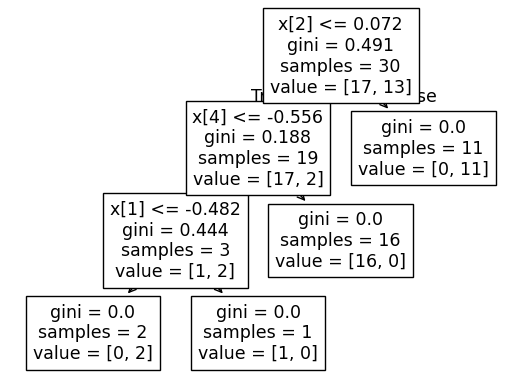

In [30]:
plot_tree(clf1)

[Text(0.5, 0.75, 'x[2] <= -0.171\ngini = 0.498\nsamples = 30\nvalue = [16, 14]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.625, 0.5, '  False')]

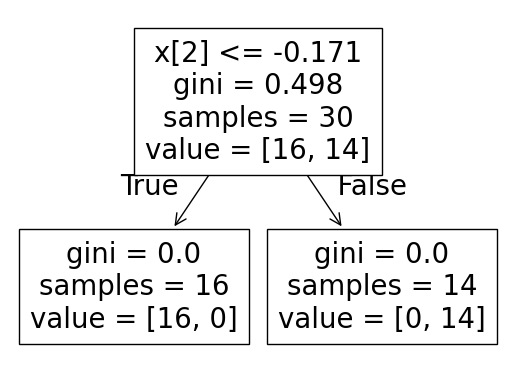

In [31]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[2] <= -0.905\ngini = 0.5\nsamples = 30\nvalue = [15, 15]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 0.387\ngini = 0.208\nsamples = 17\nvalue = [2, 15]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

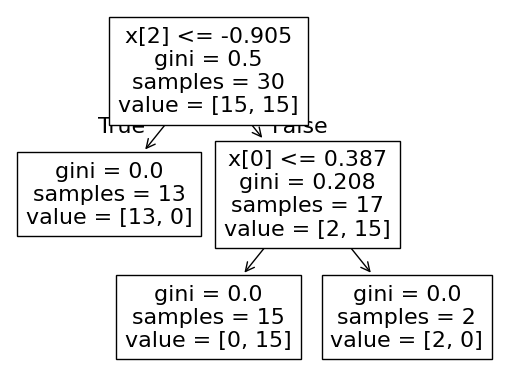

In [32]:
plot_tree(clf3)

In [10]:
# Regenerating dependencies to ensure correct kernel state
X,y = make_classification(n_features = 5,n_redundant = 0,n_informative = 5,n_clusters_per_class = 1)
df = pd.DataFrame(X,columns = ['col1','col2','col3','col4', 'col5'])
df['target'] = y

In [11]:
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace = True)

In [12]:
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [13]:
df1 = sample_rows(df,0.3)
df2 = sample_rows(df,0.3)
df3 = sample_rows(df,0.3)

In [14]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [15]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

In [16]:
input_row = np.array([1.966403, 0.470711, 2.003027, 0.846081, 0.255718]).reshape(1,5)

prediction_clf1 = clf1.predict(input_row)
prediction_clf2 = clf2.predict(input_row)
prediction_clf3 = clf3.predict(input_row)

print(f"Prediction from clf1: {prediction_clf1[0]}")
print(f"Prediction from clf2: {prediction_clf2[0]}")
print(f"Prediction from clf3: {prediction_clf3[0]}")

Prediction from clf1: 1
Prediction from clf2: 1
Prediction from clf3: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
